## Basic Bubble Chart (Matplotlib)
🔹 Core idea

Bubble area ∝ value (not radius!)

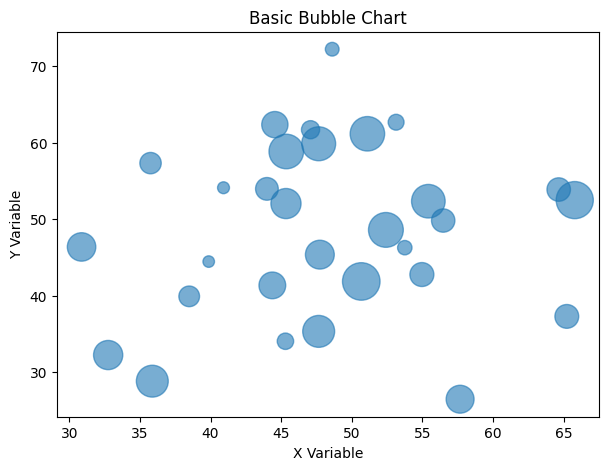

In [1]:
import numpy as np
import matplotlib.pyplot as plt

np.random.seed(42)

x = np.random.normal(50, 10, 30)
y = np.random.normal(50, 12, 30)
size = np.random.uniform(50, 800, 30)

plt.figure(figsize=(7, 5))
plt.scatter(x, y, s=size, alpha=0.6)
plt.xlabel("X Variable")
plt.ylabel("Y Variable")
plt.title("Basic Bubble Chart")
plt.show()


## Bubble Chart with Color Encoding (4th Dimension)

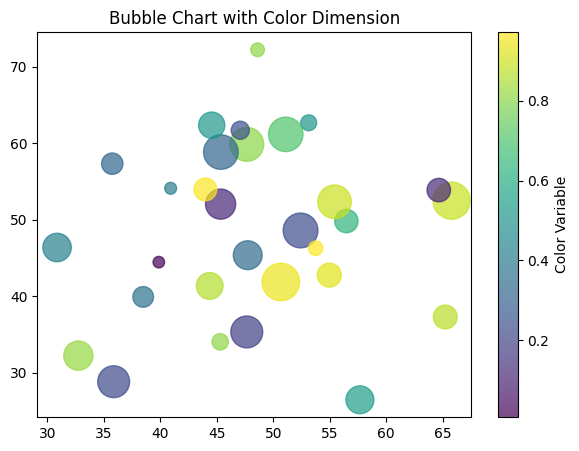

In [2]:
color = np.random.rand(30)

plt.figure(figsize=(7, 5))
plt.scatter(x, y, s=size, c=color, alpha=0.7)
plt.colorbar(label="Color Variable")
plt.title("Bubble Chart with Color Dimension")
plt.show()


## Proper Size Normalization (Best Practice)
🔹 Prevent misleading visuals

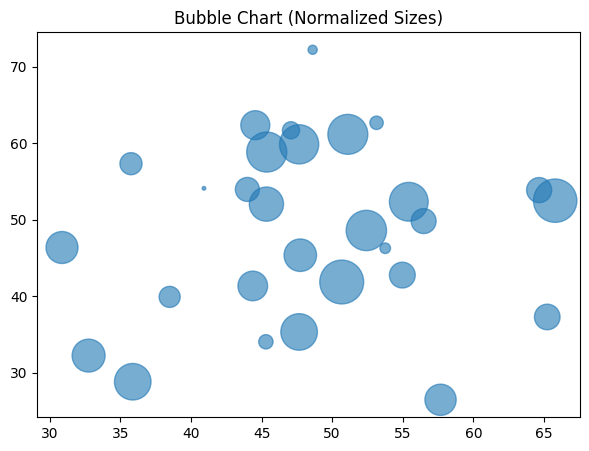

In [3]:
size_norm = 1000 * (size - size.min()) / (size.max() - size.min())

plt.figure(figsize=(7, 5))
plt.scatter(x, y, s=size_norm, alpha=0.6)
plt.title("Bubble Chart (Normalized Sizes)")
plt.show()


## Bubble Chart with Categories (Hue)

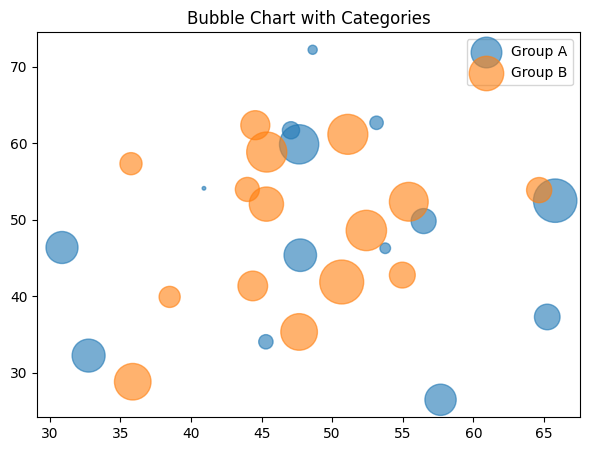

In [4]:
groups = np.random.choice(["A", "B"], 30)

plt.figure(figsize=(7, 5))
for g in np.unique(groups):
    idx = groups == g
    plt.scatter(
        x[idx], y[idx],
        s=size_norm[idx],
        alpha=0.6,
        label=f"Group {g}"
    )

plt.legend()
plt.title("Bubble Chart with Categories")
plt.show()


## Bubble Chart with Annotations (Key Points)

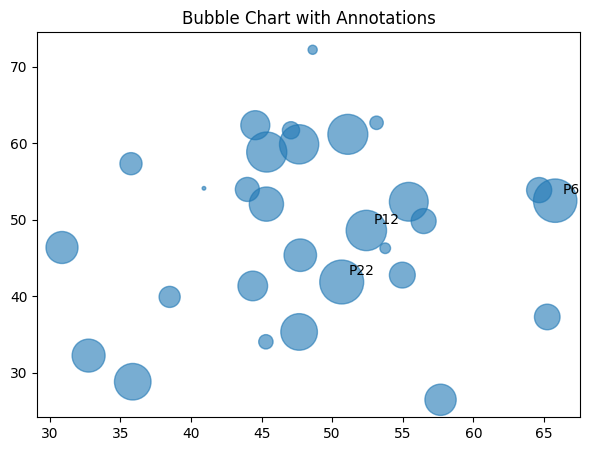

In [5]:
plt.figure(figsize=(7, 5))
plt.scatter(x, y, s=size_norm, alpha=0.6)

for i in np.argsort(size)[-3:]:
    plt.annotate(
        f"P{i}",
        (x[i], y[i]),
        xytext=(5, 5),
        textcoords="offset points"
    )

plt.title("Bubble Chart with Annotations")
plt.show()


## Bubble Chart for Time-Based Data

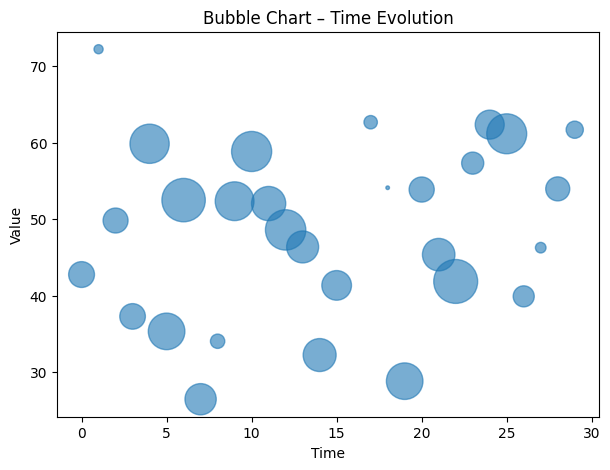

In [6]:
time = np.arange(30)

plt.figure(figsize=(7, 5))
plt.scatter(time, y, s=size_norm, alpha=0.6)
plt.xlabel("Time")
plt.ylabel("Value")
plt.title("Bubble Chart – Time Evolution")
plt.show()


## Bubble Chart for Correlation Inspection

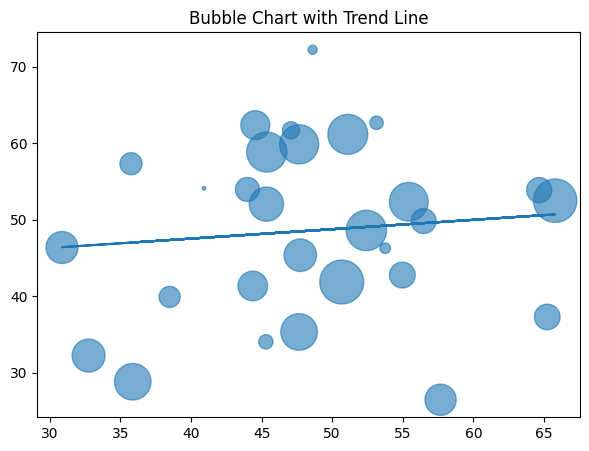

In [7]:
plt.figure(figsize=(7, 5))
plt.scatter(x, y, s=size_norm, alpha=0.6)

# Trend line
m, b = np.polyfit(x, y, 1)
plt.plot(x, m * x + b)

plt.title("Bubble Chart with Trend Line")
plt.show()


## Interactive Bubble Chart (Plotly – Recommended)
🔹 Best for exploration

In [8]:
import plotly.express as px
import pandas as pd

df = pd.DataFrame({
    "X": x,
    "Y": y,
    "Size": size,
    "Group": groups
})

fig = px.scatter(
    df,
    x="X",
    y="Y",
    size="Size",
    color="Group",
    hover_name=df.index,
    size_max=40,
    title="Interactive Bubble Chart"
)

fig.show()
